In [1]:
import pickle
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
from collections import Counter
import numpy as np
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FixedLocator, NullLocator)

from qiskit_qaoa.utils.hamiltonian_utils import get_Q_and_hamiltonian
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples

In [8]:
def plot_several_p_dist(
    axs: list[Axes], 
    vertices, ising_offset,
    prob,
    db_fixed, dg_fixed, shots,
    ps, rescale,
    max_beta_T=None, eps=None, alpha=None,
    iters=None, normalise=False
) -> list[Axes]:
    data_file = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/new_qubo_formulation/qubo_qaoa/nonvariational/phylogeny/{vertices}v_pauli.pickle'
    with open(data_file, 'rb') as f:
        hamiltonian = pickle.load(f)
    num_qubits: int = hamiltonian.num_qubits
    base_file_name = f'/lustre/scratch127/qpg/jc59/phylogeny/iter_qaoa.{vertices}v.shots{shots}.betaT{max_beta_T}.eps{eps}.alpha{alpha}.pkl'
    with open(base_file_name, 'rb') as f:
        res = pickle.load(f)
        
    sample_sequence = []
    samples_dict: dict[tuple[int, float], list[list[str]]] = res['samples_dict']
    keys = samples_dict.keys()
    energies = res['energies']
    if iters is None:
        iters = [0, 5, 9]
    energies = np.array(energies)
    if normalise:
        energies /= energies.max()
        # energies /= energies[0,0]
    
    cutoff=25
    
    for i in range(1, len(axs)):
        ax = axs[i]
        sample_sequence = []
        for p in ps:
            rescale_value = None
            for key in keys:
                if key[0] == p and np.abs(key[1] - rescale)**2 < 0.0005:
                    rescale_value = key[1]
                    break
            if rescale_value is None:
                raise Exception('Could not rescale value')
            if len(samples_dict[(p, rescale_value)]) > 3:
                counter = Counter(samples_dict[(p, rescale_value)][iters[i-1]])
            else:
                counter = Counter(samples_dict[(p, rescale_value)][i-1])
            if i == len(axs) - 1:
                print(p, counter.most_common(2))
            evals = np.round(ising_offset + evaluate_sparse_pauli_samples(list(counter.keys()), hamiltonian), 2)
            
            energies = [count * [evals[idx]] for idx, count in enumerate(counter.values()) if evals[idx] < cutoff]
            sample_vals = np.array([x for xs in energies for x in xs])
            quasi_sample_vals = np.sort(sample_vals)[:int(alpha * len(sample_vals))]
            sample_sequence.append(quasi_sample_vals)

        min_val = min(min(x) for x in sample_sequence)
        ax.hist(sample_sequence, bins=range(min_val, cutoff+1), weights=[[1/shots]*len(sample_vals) for sample_vals in sample_sequence], rwidth=1, log=True, label=ps)
        ax.set_xlim(min_val, cutoff)
        ax.set_ylim(1/shots, 10**0)

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.tick_params(axis='x', which='major', length=6)
        ax.tick_params(axis='x', which='minor', length=2)
        ax.text(.95, .99, f'Iter = {iters[i-1] + 1}', ha='right', va='top', transform=ax.transAxes)
        
        
    ax = axs[0]
    rand_shots = min(shots*10, 40000)
    random_samples = np.random.choice(('0', '1'), (rand_shots, num_qubits), p=(1-prob,prob))
    rand_samples = [''.join(sample) for sample in random_samples]
    rand_vals = np.round(ising_offset + evaluate_sparse_pauli_samples(rand_samples, hamiltonian), 2)
    ax.hist(rand_vals, bins=range(cutoff+1), weights=[1/rand_shots]*len(rand_vals), rwidth=1, log=True, color='gray')
    ax.set_xlim(0, cutoff)
    ax.set_ylim(1/shots, 10**0)

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.text(.95, .99, 'Iter = 0', ha='right', va='top', transform=ax.transAxes)
    
         
    ax.legend(loc='best', bbox_to_anchor=(0.8, 0.6, 0.2, 0.4))
    return axs

TypeError: 'numpy.float64' object cannot be interpreted as an integer

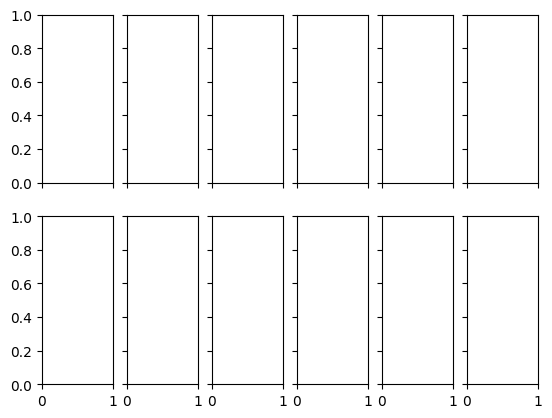

In [9]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 40000
ps = [1,3,5]
iters=range(5)
max_beta_T = 0.15
# ENERGIES ** 2, warm start

fig, axs = plt.subplots(2, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]

plot_several_p_dist(axs0, 64, 202, 1/2, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, eps=0.15, alpha=0.1,iters=iters)



for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [64, 0]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = 1,3,5, n = 4000$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()
